In [10]:
%load_ext autoreload
%autoreload 2
import soccer_pattern_recognition as sc

import os
import time
import tqdm
import numpy as np
import pandas as pd

from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import socceraction.spadl as spadl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
datafolder = "../data"
fifa2018h5 = os.path.join(datafolder, "spadl-fifa2018.h5")
games = pd.read_hdf(fifa2018h5, key="games")
with pd.HDFStore(fifa2018h5) as store:
    actions = []  #list of DataFrames
    for game in tqdm.tqdm(games.itertuples()):
        game_action = store[f"actions/game_{game.game_id}"]
        game_action = spadl.play_left_to_right(game_action, game.home_team_id)
        game_action["is_home"] = game_action["team_id"] == game.home_team_id
        actions.append(game_action)
    actions = pd.concat(actions)
    actions.drop("original_event_id", axis=1, inplace=True)
    actions = pd.merge(actions, spadl.config.actiontypes_df(), how="left")

64it [00:00, 179.31it/s]


In [12]:
def consolidate(actions):
    #actions.fillna(0, inplace=True)

    #Consolidate corner_short and corner_crossed
    corner_idx = actions.type_name.str.contains("corner")
    actions["type_name"] = actions["type_name"].mask(corner_idx, "corner")

    #Consolidate freekick_short, freekick_crossed, and shot_freekick
    freekick_idx = actions.type_name.str.contains("freekick")
    actions["type_name"] = actions["type_name"].mask(freekick_idx, "freekick")

    #Consolidate keeper_claim, keeper_punch, keeper_save, keeper_pick_up
    keeper_idx = actions.type_name.str.contains("keeper")
    actions["type_name"] = actions["type_name"].mask(keeper_idx, "keeper_action")

    actions["start_x"] = actions["start_x"].mask(actions.type_name == "shot_penalty", 94.5)
    actions["start_y"] = actions["start_y"].mask(actions.type_name == "shot_penalty", 34)

    return actions


actions = consolidate(actions)

def add_noise(actions):
    # Start locations
    start_list = ["cross", "shot", "dribble", "pass", "keeper_action", "clearance", "goalkick"]
    mask = actions["type_name"].isin(start_list)
    noise = np.random.normal(0, 0.5, size=actions.loc[mask, ["start_x", "start_y"]].shape)
    actions.loc[mask, ["start_x", "start_y"]] += noise

    # End locations
    end_list = ["cross", "shot", "dribble", "pass", "keeper_action", "throw_in", "corner", "freekick", "shot_penalty"]
    mask = actions["type_name"].isin(end_list)
    noise = np.random.normal(0, 0.5, size=actions.loc[mask, ["end_x", "end_y"]].shape)
    actions.loc[mask, ["end_x", "end_y"]] += noise

    return actions

actions = add_noise(actions)

def remove_outliers(actions, verbose=False):
    X = actions[["start_x","start_y","end_x","end_y"]].to_numpy(dtype=float)
    inliers = LocalOutlierFactor(contamination="auto").fit_predict(X)
    if verbose:
        print(f"Remove {(inliers==-1).sum()} out of {X.shape[0]} datapoints.")
    return actions[inliers==1]

actions = remove_outliers(actions,True)

Remove 571 out of 128484 datapoints.


In [13]:
actions[["type_id", "type_name"]].drop_duplicates().sort_values("type_id")

,type_id,type_name
0,0,pass
80,1,cross
149,2,throw_in
99,3,freekick
154,4,freekick
140,5,corner
3908,6,corner
128,7,take_on
98,8,foul
129,9,tackle


In [14]:
actions["angle"] = np.arctan2(actions.end_y - actions.start_y, actions.end_x - actions.start_x)
actions["cos_angle"] = np.cos(actions["angle"])
actions["sin_angle"] = np.sin(actions["angle"])

ACTION_MAP = {'clearance': 0,
              'corner': 1,
              'cross': 2,
              'dribble': 3,
              'freekick': 4,
              'goalkick': 5,
              'keeper_action': 6,
              'pass': 7,
              'shot': 8,
              'throw_in': 9}

actions["action_type_id"] = actions["type_name"].map(ACTION_MAP)

In [15]:
actions.groupby("type_name").size()

type_name
bad_touch         1547
clearance         2040
corner             526
cross             1287
dribble          52519
foul              1876
freekick          1262
goalkick           676
interception      1681
keeper_action      582
pass             56231
shot              1525
shot_penalty        68
tackle            1830
take_on           2109
throw_in          2154
dtype: int64

In [16]:


action_set = set(ACTION_MAP.keys())

mask = (actions['game_id'] == 7585) & (actions['period_id']==1 & (actions['type_name'].isin(action_set)))

print(actions[mask]["type_name"].unique())
print(actions[mask].size)

['pass' 'dribble' 'cross' 'clearance' 'freekick' 'keeper_action' 'corner'
 'throw_in' 'shot' 'goalkick']
17043


In [17]:
data = actions[mask][["action_type_id","start_x", "start_y","cos_angle", "sin_angle"]].to_numpy()

In [25]:
emission_hyperparams = {'clearance': [4, "k-means",2,"k-means"],
              'corner': [2, "k-means",2,"k-means"],
              'cross': [4, "k-means",2,"k-means"],
              'dribble': [5, "k-means",2,"k-means"],
              'freekick': [3, "k-means",2,"k-means"],
              'goalkick': [2, "k-means",2,"k-means"],
              'keeper_action': [3, "k-means",2,"k-means"],
              'pass': [5, "k-means",2,"k-means"],
              'shot': [3, "k-means",2,"k-means"],
              'throw_in': [6, "k-means",2,"k-means"]}

model = sc.TwoLayerHMM(emission_hyperparams,2)

In [26]:
model.fit(data)

/Users/jgv/PycharmProjects/soccer-pattern-recognition/src/soccer_pattern_recognition/hierarchical/two_layer.py:449: RuntimeWarning: divide by zero encountered in log
  return logsumexp(np.log(layer1_pdf) + layer2_log_pdf, axis=1)  # (N,)


,emission_hyperparams,"{'clearance': [4, 'k-means', ...], 'corner': [2, 'k-means', ...], 'cross': [4, 'k-means', ...], 'dribble': [5, 'k-means', ...], ...}"
,n_components,2
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,None
,n_iter,10
,tol,0.01
,verbose,False
,params,'stam'
,init_params,'stam'


In [27]:
for action in ACTION_MAP.keys():
    for state in range(2):
        print(f"State: {state}, {action}")
        print(model.emission.action_mom_[state][action].layer1_mixture)
        print(model.emission.action_mom_[state][action].layer2_mixtures)

State: 0, clearance
MixtureModel(n_components=4)
  ├─ (0) w=0.272  MultivariateGaussian(d=2, mean=[ 7.861 27.977], cov=[[ 0.221 -1.622], [ -1.622 153.307]])
  ├─ (1) w=0.214  MultivariateGaussian(d=2, mean=[13.967 34.721], cov=[[  2.625 -10.669], [-10.669  45.046]])
  ├─ (2) w=0.263  MultivariateGaussian(d=2, mean=[ 7.481 39.227], cov=[[ 5.328 -3.024], [-3.024  7.257]])
  └─ (3) w=0.251  MultivariateGaussian(d=2, mean=[15.178 39.035], cov=[[ 4.062 15.151], [15.151 61.721]])
[MixtureModel(n_components=2)
  ├─ (0) w=0.000  VonMises(loc=-97.7 deg, kappa=50.000)
  └─ (1) w=1.000  VonMises(loc=-3.3 deg, kappa=50.000), MixtureModel(n_components=2)
  ├─ (0) w=0.979  VonMises(loc=-65.1 deg, kappa=50.000)
  └─ (1) w=0.021  VonMises(loc=-58.0 deg, kappa=18.229), MixtureModel(n_components=2)
  ├─ (0) w=0.117  VonMises(loc=-97.7 deg, kappa=50.000)
  └─ (1) w=0.883  VonMises(loc=77.7 deg, kappa=5.878), MixtureModel(n_components=2)
  ├─ (0) w=0.000  VonMises(loc=-67.3 deg, kappa=50.000)
  └─ (1) w=1

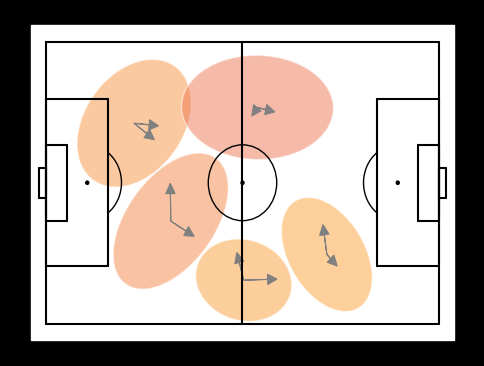

In [28]:
model.emission.action_mom_[0]["pass"].plot()

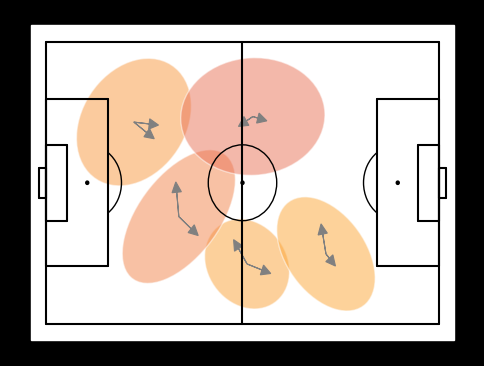

In [29]:
model.emission.action_mom_[1]["pass"].plot()